# I Want to Learn how price behave with age and kms driven

1️⃣ Do prices decline linearly with age?

2️⃣ Are low-kilometer cars irrationally overpriced?

3️⃣ Is there fuel-type pricing bias?

4️⃣ Is there city-level price inflation?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

In [2]:
df=  pd.read_csv(r"C:\Users\AION\Desktop\skills\used_car_dataset.csv")
df

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture
0,Hyundai Grand i10 Magna 1.2 Kappa VTVT [2017-2...,₹ 4.45 Lakh,"22,402 km",Petrol,Mumbai,2016
1,Maruti Suzuki Alto 800 Lxi,₹ 2.93 Lakh,"10,344 km",Petrol,Kolkata,2019
2,Tata Safari XZ Plus New,₹ 22.49 Lakh,"12,999 km",Diesel,Bangalore,2021
3,Maruti Suzuki Ciaz ZXI+,₹ 6.95 Lakh,"45,000 km",Petrol,Thane,2016
4,Jeep Compass Sport Plus 1.4 Petrol [2019-2020],₹ 12 Lakh,"11,193 km",Petrol,Kolkata,2019
...,...,...,...,...,...,...
2100,Ford Figo Titanium1.5 TDCi,₹ 3.6 Lakh,"42,158 km",Diesel,Kolkata,2015
2101,MINI Cooper Countryman Cooper D,₹ 22 Lakh,"68,862 km",Diesel,Hyderabad,2013
2102,Hyundai Verna 1.6 VTVT SX,₹ 8.38 Lakh,"37,622 km",Petrol,Chennai,2018
2103,Maruti Suzuki Ciaz VXi+ AT,₹ 6.75 Lakh,"64,726 km",Petrol,Mumbai,2017


In [3]:
df.shape

(2105, 6)

In [4]:
df.head()

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture
0,Hyundai Grand i10 Magna 1.2 Kappa VTVT [2017-2...,₹ 4.45 Lakh,"22,402 km",Petrol,Mumbai,2016
1,Maruti Suzuki Alto 800 Lxi,₹ 2.93 Lakh,"10,344 km",Petrol,Kolkata,2019
2,Tata Safari XZ Plus New,₹ 22.49 Lakh,"12,999 km",Diesel,Bangalore,2021
3,Maruti Suzuki Ciaz ZXI+,₹ 6.95 Lakh,"45,000 km",Petrol,Thane,2016
4,Jeep Compass Sport Plus 1.4 Petrol [2019-2020],₹ 12 Lakh,"11,193 km",Petrol,Kolkata,2019


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   car_name             2105 non-null   object
 1   car_price_in_rupees  2105 non-null   object
 2   kms_driven           2105 non-null   object
 3   fuel_type            2105 non-null   object
 4   city                 2105 non-null   object
 5   year_of_manufacture  2105 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 98.8+ KB


In [6]:
df.describe()


,year_of_manufacture
count,2105.000000
mean,2017.022803
std,2.818066
min,2004.000000
25%,2015.000000
50%,2017.000000
75%,2019.000000
max,2022.000000


In [7]:
df.value_counts()

car_name                                                 car_price_in_rupees  kms_driven  fuel_type  city       year_of_manufacture
Skoda Rapid Ambition 1.6 MPI AT                          ₹ 8.99 Lakh          57,702 km   Petrol     Bangalore  2018                   2
Maruti Suzuki Baleno Zeta 1.2                            ₹ 4.83 Lakh          57,052 km   Petrol     Kolkata    2016                   2
Mercedes-Benz C-Class 250 CDI Avantagarde                ₹ 9.5 Lakh           99,941 km   Diesel     Ahmedabad  2012                   2
Hyundai Grand i10 Magna 1.2 Kappa VTVT CNG [2019-2020]   ₹ 7.78 Lakh          8,423 km    CNG        Pune       2021                   2
Mercedes-Benz CLA 200 CDI Sport                          ₹ 16.49 Lakh         51,500 km   Diesel     Kolkata    2015                   2
                                                                                                                                      ..
Hyundai Grand i10 Sportz (O) 1.2 Kappa VTVT [2

# Clean data:

1. rupees is taken as object but must be int

2. kms must be int

optional:

3. remove carmodel+ brand to create car brand and car model

In [8]:
df['car_price_in_rupees']

0        ₹ 4.45 Lakh
1        ₹ 2.93 Lakh
2       ₹ 22.49 Lakh
3        ₹ 6.95 Lakh
4          ₹ 12 Lakh
            ...     
2100      ₹ 3.6 Lakh
2101       ₹ 22 Lakh
2102     ₹ 8.38 Lakh
2103     ₹ 6.75 Lakh
2104     ₹ 8.76 Lakh
Name: car_price_in_rupees, Length: 2105, dtype: object

In [9]:
def car_price_transformation(price):
    price = price.replace('₹','').strip()

    if "Crore" in price:
        value = float(price.replace("Crore",'').strip())
        return value*10000000

    elif "Lakh" in price:
        value = float(price.replace("Lakh","").strip())
        return value*100000

    else:
        return None
        

In [10]:
df['price'] = df['car_price_in_rupees'].apply(car_price_transformation)
df['price']

0        445000.0
1        293000.0
2       2249000.0
3        695000.0
4       1200000.0
          ...    
2100     360000.0
2101    2200000.0
2102     838000.0
2103     675000.0
2104     876000.0
Name: price, Length: 2105, dtype: float64

In [11]:
df['price'].describe()

count    2.103000e+03
mean     1.132423e+06
std      1.343602e+06
min      1.100000e+05
25%      4.750000e+05
50%      6.990000e+05
75%      1.150000e+06
max      1.950000e+07
Name: price, dtype: float64

In [12]:
df[df['car_price_in_rupees'].str.contains('Crore')]

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture,price
21,Porsche 718 Boxster,₹ 1.15 Crore,"6,500 km",Petrol,Pune,2020,11500000.0
313,Land Rover Range Rover Sport SDV6 SE,₹ 1.23 Crore,"39,012 km",Diesel,Thane,2019,12300000.0
1340,Mercedes-Benz S-Class Maybach S 500,₹ 1.19 Crore,"24,500 km",Petrol,Kolkata,2017,11900000.0
1392,Land Rover Range Rover 4.4 SDV8 Autobiography LWB,₹ 1.95 Crore,"45,000 km",Diesel,Ahmedabad,2018,19500000.0
1850,Land Rover Range Rover Sport SE 3.0 Diesel [20...,₹ 1.36 Crore,"36,000 km",Diesel,Bangalore,2019,13600000.0


In [13]:
df['kms_driven']

0       22,402 km
1       10,344 km
2       12,999 km
3       45,000 km
4       11,193 km
          ...    
2100    42,158 km
2101    68,862 km
2102    37,622 km
2103    64,726 km
2104    29,150 km
Name: kms_driven, Length: 2105, dtype: object

In [14]:
df['kms_driven_new']= (df['kms_driven'].str.replace('km','').str.replace(',','').astype(int))
df['kms_driven_new']

0       22402
1       10344
2       12999
3       45000
4       11193
        ...  
2100    42158
2101    68862
2102    37622
2103    64726
2104    29150
Name: kms_driven_new, Length: 2105, dtype: int64

In [15]:
def car_brand(df):

    mask = df['car_name'].str.startswith(('Land','MINI'))

    df.loc[mask, 'brand'] = df.loc[mask, 'car_name'].str.split().str[:2].str.join(' ')
    df.loc[~mask, 'brand'] = df.loc[~mask, 'car_name'].str.split().str[0]

    return df


In [16]:
car_brand(df)

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture,price,kms_driven_new,brand
0,Hyundai Grand i10 Magna 1.2 Kappa VTVT [2017-2...,₹ 4.45 Lakh,"22,402 km",Petrol,Mumbai,2016,445000.0,22402,Hyundai
1,Maruti Suzuki Alto 800 Lxi,₹ 2.93 Lakh,"10,344 km",Petrol,Kolkata,2019,293000.0,10344,Maruti
2,Tata Safari XZ Plus New,₹ 22.49 Lakh,"12,999 km",Diesel,Bangalore,2021,2249000.0,12999,Tata
3,Maruti Suzuki Ciaz ZXI+,₹ 6.95 Lakh,"45,000 km",Petrol,Thane,2016,695000.0,45000,Maruti
4,Jeep Compass Sport Plus 1.4 Petrol [2019-2020],₹ 12 Lakh,"11,193 km",Petrol,Kolkata,2019,1200000.0,11193,Jeep
...,...,...,...,...,...,...,...,...,...
2100,Ford Figo Titanium1.5 TDCi,₹ 3.6 Lakh,"42,158 km",Diesel,Kolkata,2015,360000.0,42158,Ford
2101,MINI Cooper Countryman Cooper D,₹ 22 Lakh,"68,862 km",Diesel,Hyderabad,2013,2200000.0,68862,MINI Cooper
2102,Hyundai Verna 1.6 VTVT SX,₹ 8.38 Lakh,"37,622 km",Petrol,Chennai,2018,838000.0,37622,Hyundai
2103,Maruti Suzuki Ciaz VXi+ AT,₹ 6.75 Lakh,"64,726 km",Petrol,Mumbai,2017,675000.0,64726,Maruti


In [17]:
def car_names(df):

    mask = df['car_name'].str.startswith(('MINI','Land'))

    df.loc[mask, 'car_names'] = df.loc[mask, 'car_name'].str.split().str[2:].str.join(' ')
    df.loc[~mask, 'car_names'] = df.loc[~mask, 'car_name'].str.split().str[1:].str.join(' ')

    return df


In [18]:
car_names(df)

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture,price,kms_driven_new,brand,car_names
0,Hyundai Grand i10 Magna 1.2 Kappa VTVT [2017-2...,₹ 4.45 Lakh,"22,402 km",Petrol,Mumbai,2016,445000.0,22402,Hyundai,Grand i10 Magna 1.2 Kappa VTVT [2017-2020]
1,Maruti Suzuki Alto 800 Lxi,₹ 2.93 Lakh,"10,344 km",Petrol,Kolkata,2019,293000.0,10344,Maruti,Suzuki Alto 800 Lxi
2,Tata Safari XZ Plus New,₹ 22.49 Lakh,"12,999 km",Diesel,Bangalore,2021,2249000.0,12999,Tata,Safari XZ Plus New
3,Maruti Suzuki Ciaz ZXI+,₹ 6.95 Lakh,"45,000 km",Petrol,Thane,2016,695000.0,45000,Maruti,Suzuki Ciaz ZXI+
4,Jeep Compass Sport Plus 1.4 Petrol [2019-2020],₹ 12 Lakh,"11,193 km",Petrol,Kolkata,2019,1200000.0,11193,Jeep,Compass Sport Plus 1.4 Petrol [2019-2020]
...,...,...,...,...,...,...,...,...,...,...
2100,Ford Figo Titanium1.5 TDCi,₹ 3.6 Lakh,"42,158 km",Diesel,Kolkata,2015,360000.0,42158,Ford,Figo Titanium1.5 TDCi
2101,MINI Cooper Countryman Cooper D,₹ 22 Lakh,"68,862 km",Diesel,Hyderabad,2013,2200000.0,68862,MINI Cooper,Countryman Cooper D
2102,Hyundai Verna 1.6 VTVT SX,₹ 8.38 Lakh,"37,622 km",Petrol,Chennai,2018,838000.0,37622,Hyundai,Verna 1.6 VTVT SX
2103,Maruti Suzuki Ciaz VXi+ AT,₹ 6.75 Lakh,"64,726 km",Petrol,Mumbai,2017,675000.0,64726,Maruti,Suzuki Ciaz VXi+ AT


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             2105 non-null   object 
 1   car_price_in_rupees  2105 non-null   object 
 2   kms_driven           2105 non-null   object 
 3   fuel_type            2105 non-null   object 
 4   city                 2105 non-null   object 
 5   year_of_manufacture  2105 non-null   int64  
 6   price                2103 non-null   float64
 7   kms_driven_new       2105 non-null   int64  
 8   brand                2105 non-null   object 
 9   car_names            2105 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 164.6+ KB


In [20]:
df.isnull().sum()

car_name               0
car_price_in_rupees    0
kms_driven             0
fuel_type              0
city                   0
year_of_manufacture    0
price                  2
kms_driven_new         0
brand                  0
car_names              0
dtype: int64

In [21]:
df.isnull().mean()*100

car_name               0.000000
car_price_in_rupees    0.000000
kms_driven             0.000000
fuel_type              0.000000
city                   0.000000
year_of_manufacture    0.000000
price                  0.095012
kms_driven_new         0.000000
brand                  0.000000
car_names              0.000000
dtype: float64

In [22]:
df.dropna(subset = ['price'], inplace = True)

# UniVariate Analysis

# 1. Price distribution

In [23]:
df['price'].describe()

count    2.103000e+03
mean     1.132423e+06
std      1.343602e+06
min      1.100000e+05
25%      4.750000e+05
50%      6.990000e+05
75%      1.150000e+06
max      1.950000e+07
Name: price, dtype: float64

In [24]:
df['price'].skew()

np.float64(4.456171699848789)

In [25]:
a = df['price']

<Axes: xlabel='price', ylabel='Count'>

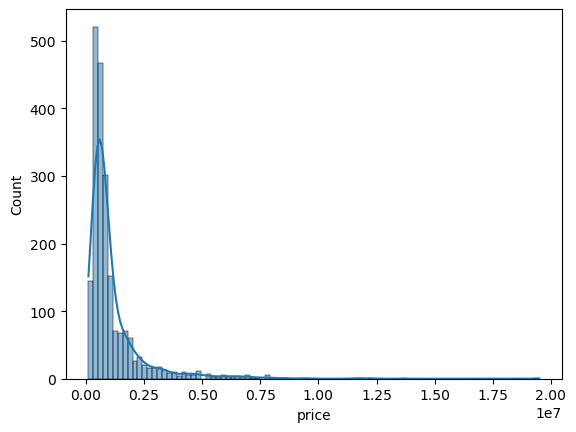

In [26]:
sns.histplot(data = a, kde = True)

# 2. Kms Driven Distribution

In [27]:
df["kms_driven_new"].describe()

count    2.103000e+03
mean     4.830968e+04
std      8.375922e+04
min      6.400000e+01
25%      2.497350e+04
50%      4.282500e+04
75%      6.300000e+04
max      3.600000e+06
Name: kms_driven_new, dtype: float64

In [28]:
df['kms_driven_new'].skew()

np.float64(36.56892942912262)

In [29]:
sns.histplot(data = df['kms_driven_new'], kde = True)

<Axes: xlabel='kms_driven_new', ylabel='Count'>

Error in callback <function flush_figures at 0x0000023E25769DA0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [30]:
df[df['kms_driven_new'] == 150000]

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture,price,kms_driven_new,brand,car_names
1133,Maruti Suzuki Wagon R LXi Minor,₹ 1.5 Lakh,"1,50,000 km",Petrol + 1,Ambattur,2007,150000.0,150000,Maruti,Suzuki Wagon R LXi Minor


# 3. Car Age distribution

<Axes: xlabel='year_of_manufacture', ylabel='Count'>

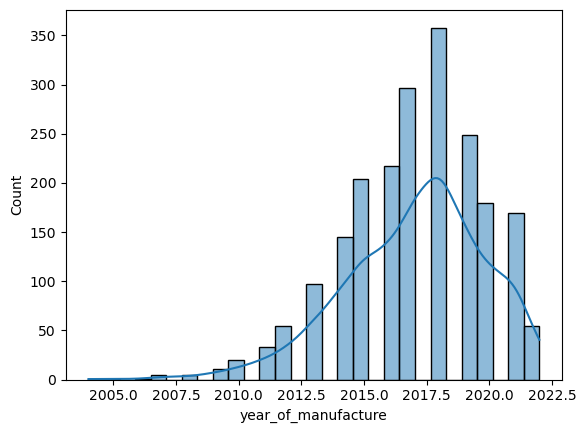

In [31]:
sns.histplot(data = df['year_of_manufacture'], kde = True)

# 4. Fuel Type

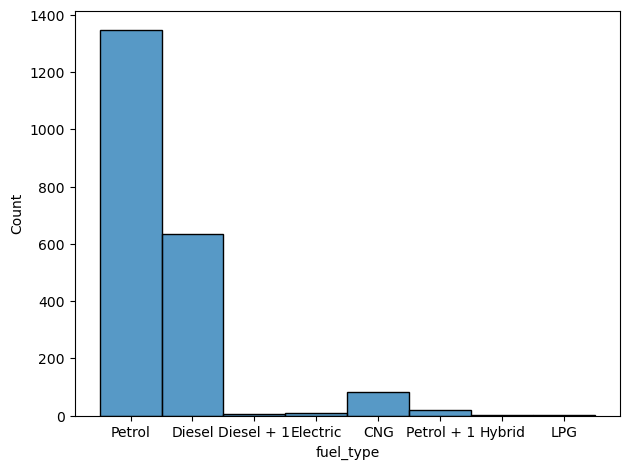

In [32]:
sns.histplot(data = df['fuel_type'])
plt.tight_layout()

# BiVariate Analysis

# 1. km vs price

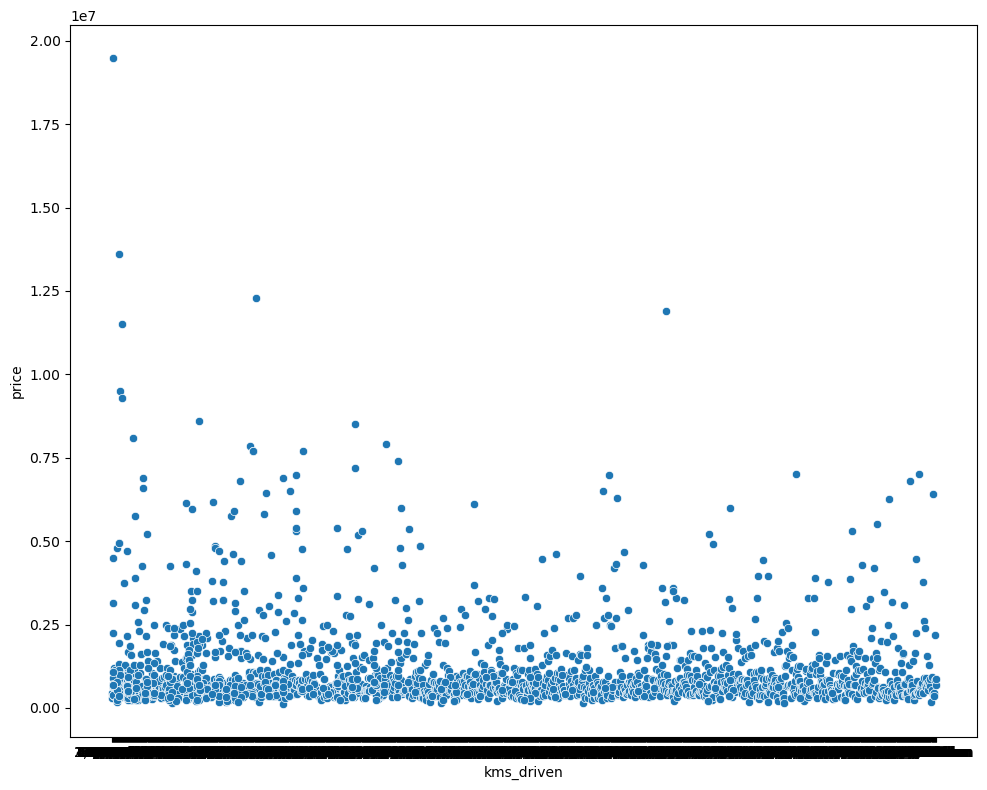

In [33]:
plt.figure(figsize = (10,8))
sns.scatterplot(x = 'kms_driven', y = 'price', data = df)
plt.tight_layout()

interpretations: 

1. high kms doesnt necessarily mean low price
2. there are cars with high cost and less kms divren
3. most used cars lie in affrdable range
4. price depends on multiple other factors

# 2. brand vs price

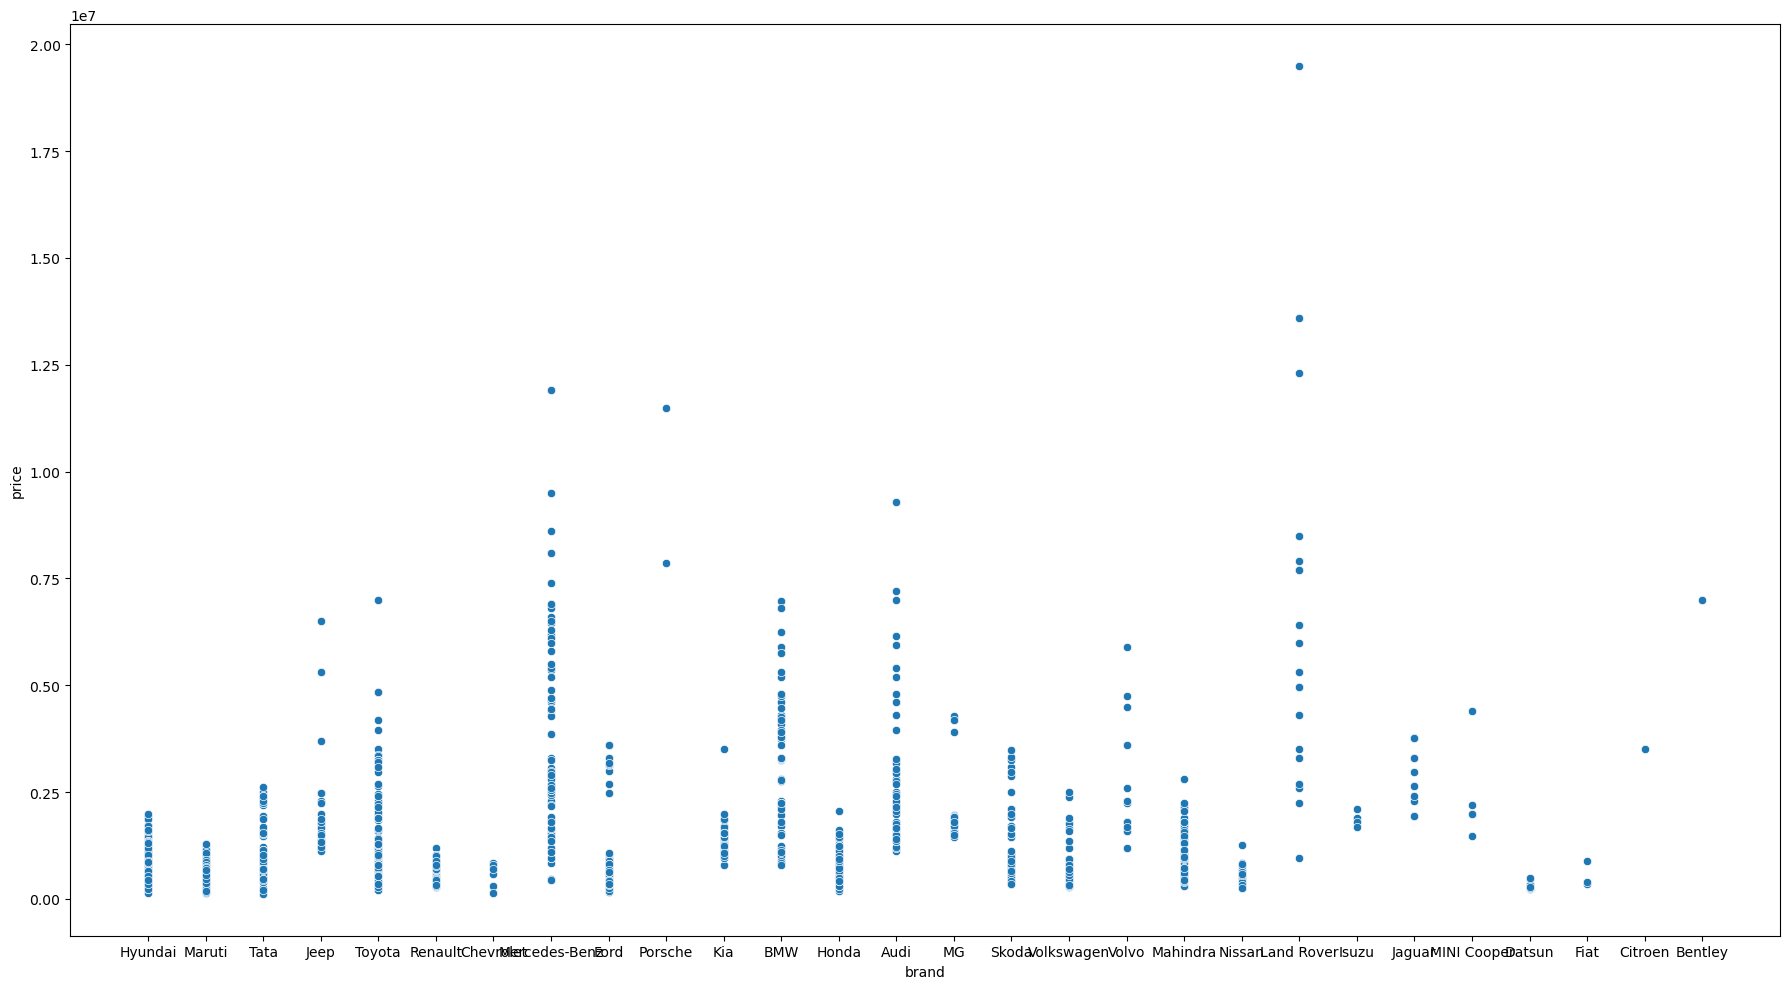

In [34]:
plt.figure(figsize = (18,10))
sns.scatterplot(x = 'brand', y = 'price', data = df)
plt.tight_layout()

interpretations:

1. majority brands have cars in affordable range, the price depends on multiple factors 
2. some brands clearly are more expensive than oter like audi, porsche, land rover
3. Price Variation Within Same Brand like toyota 

# 3. age vs price

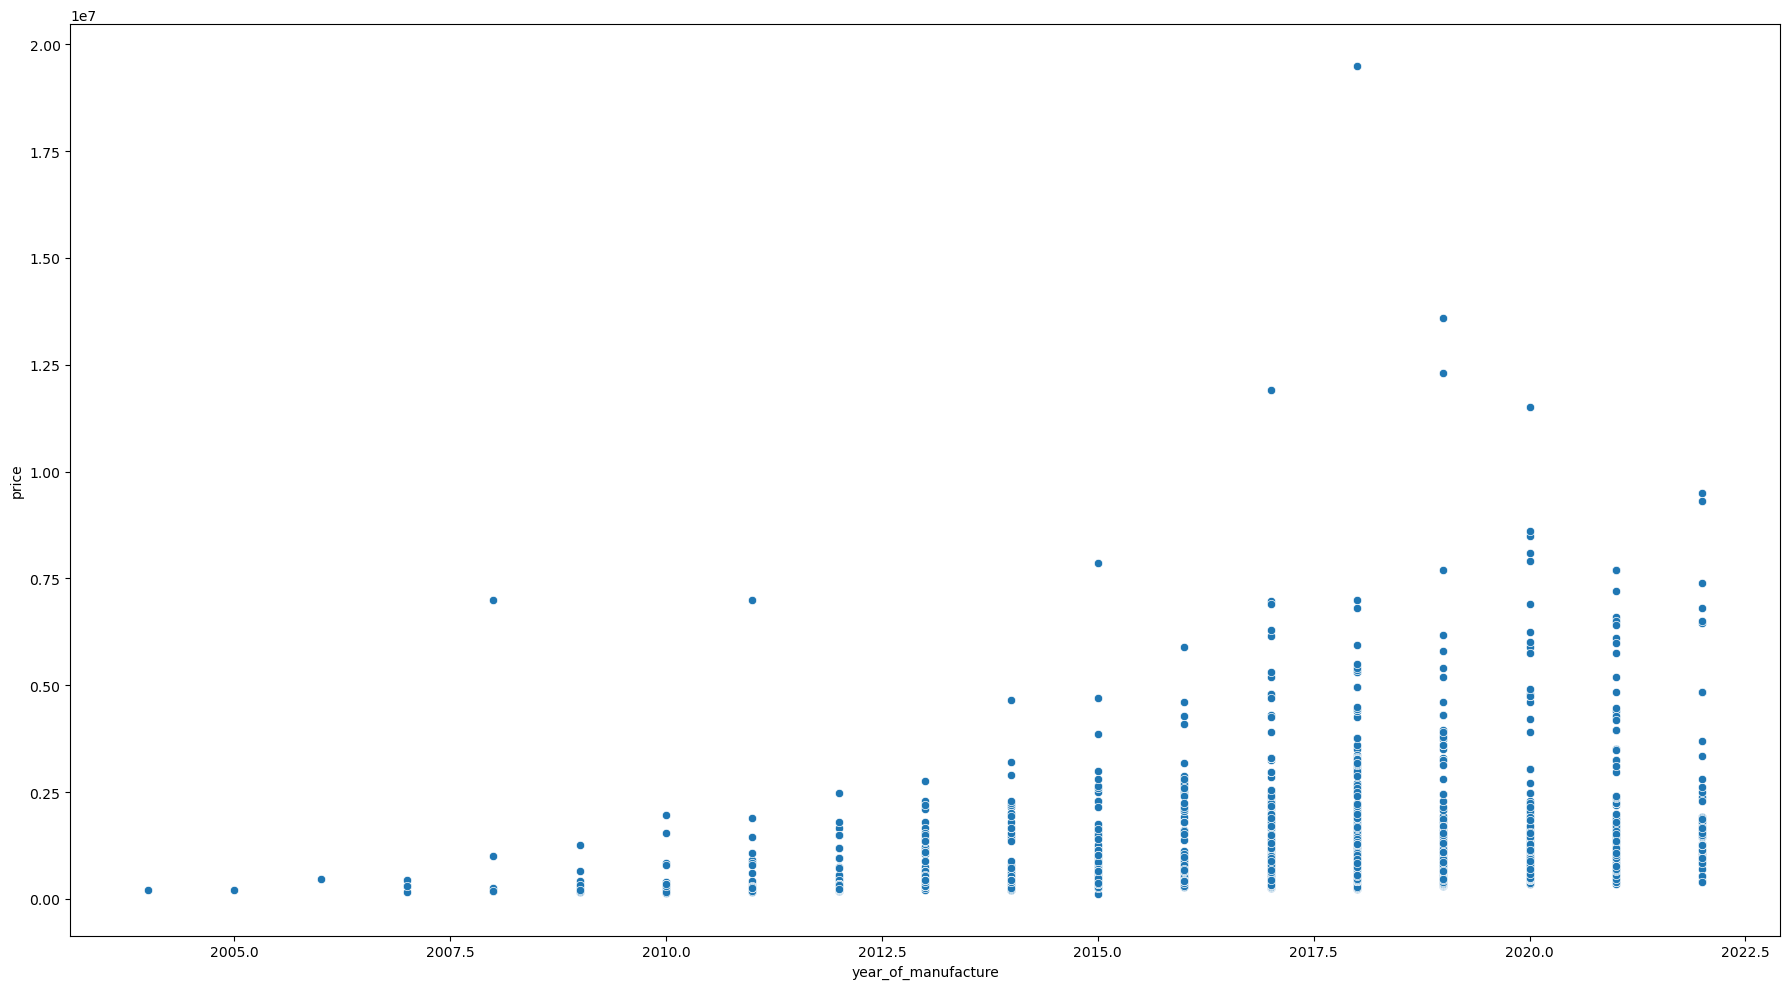

In [35]:
plt.figure(figsize = (18,10))
sns.scatterplot(x = 'year_of_manufacture', y = 'price', data = df)
plt.tight_layout()

interpretations:

1. strong relation. newer cars are higher in cost
2. shows old cars depriciate in value
3. newer cars have wider vertical spred. this is due to budget base models.

# 4. fuel_type vs price

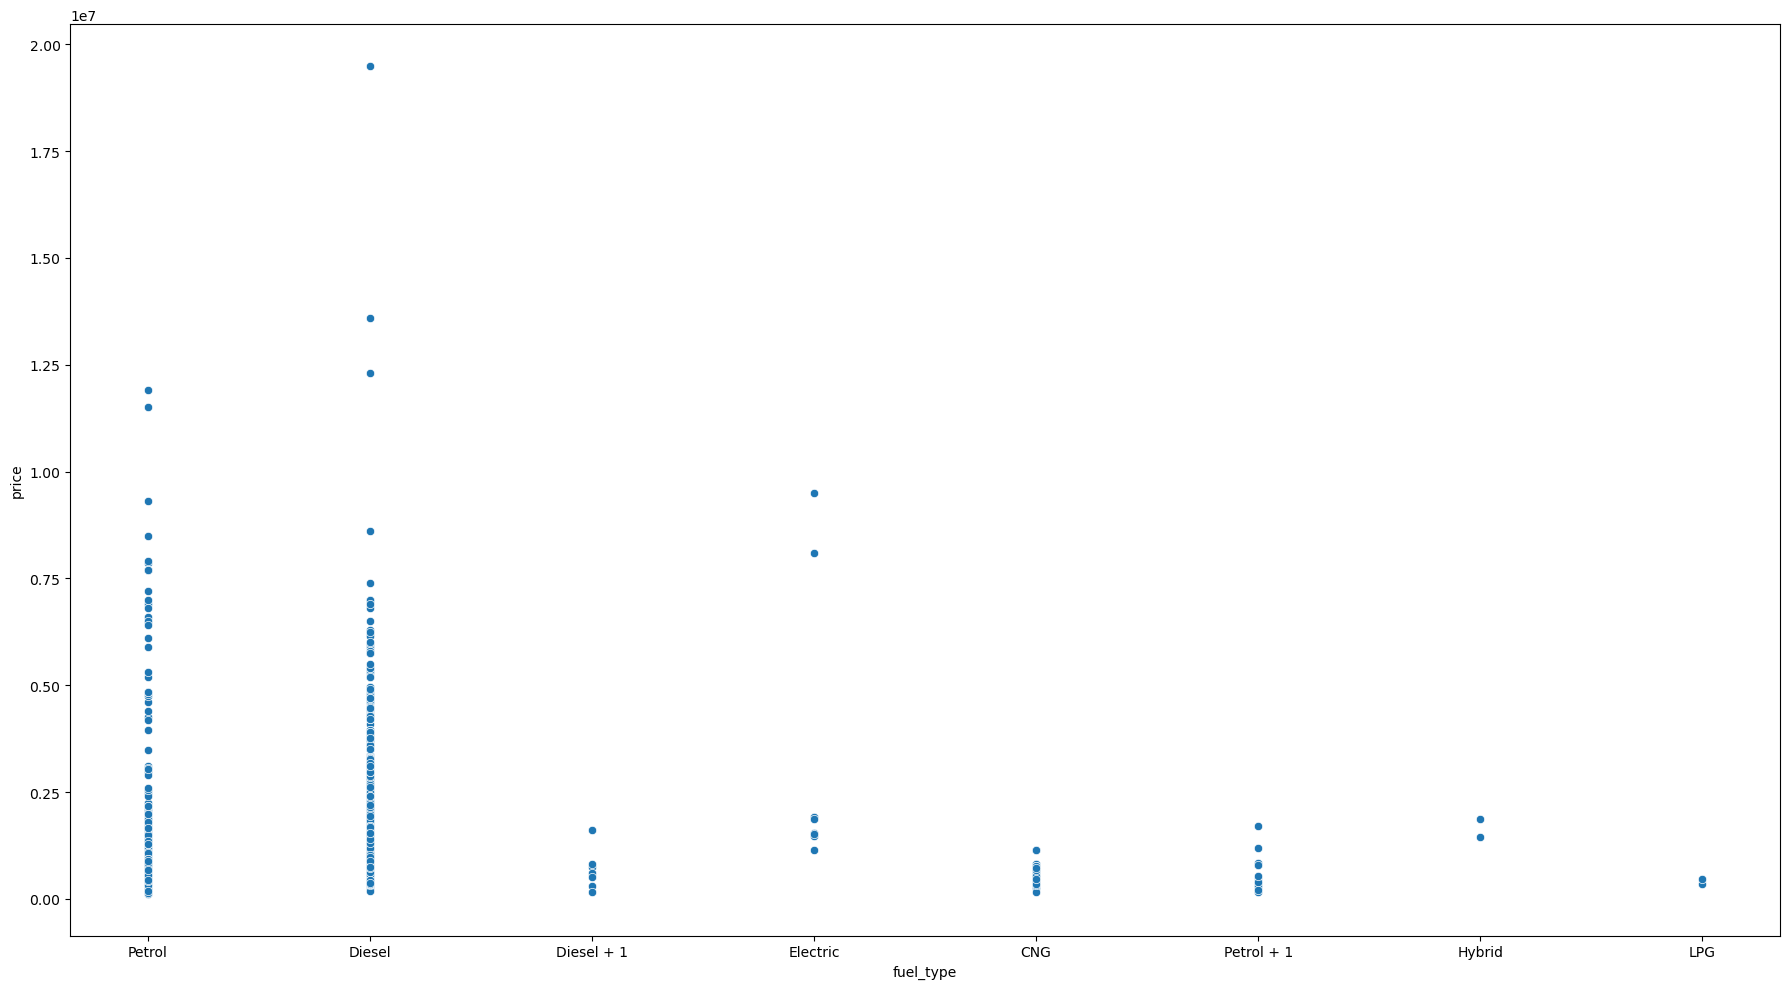

In [36]:
plt.figure(figsize = (18,10))
sns.scatterplot(x = 'fuel_type', y = 'price', data = df)
plt.tight_layout()

interpretation:

1. petrol and diesel cars cost more
2.  electric can be costlier

# 5. city vs price

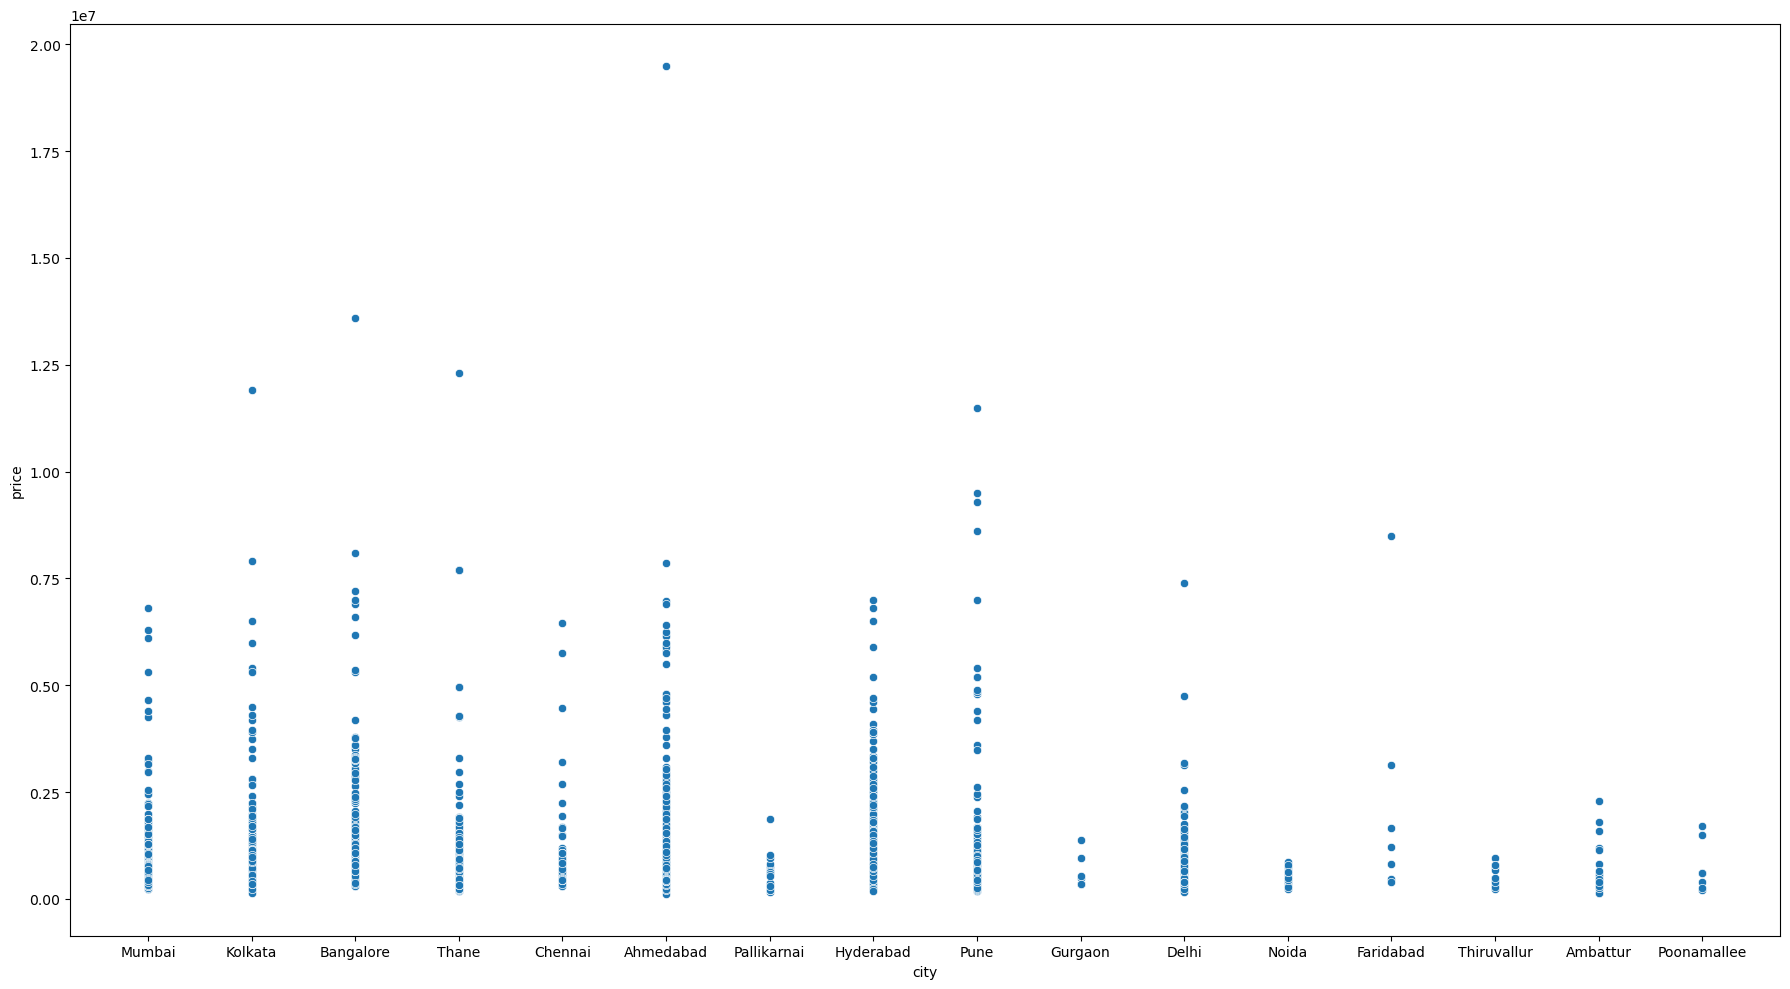

In [37]:
plt.figure(figsize = (18,10))
sns.scatterplot(x = 'city', y = 'price', data = df)
plt.tight_layout()

# Feature Engineering

1. year of maufacture = Age
2. kms/age = kms per year
3. log on price to compress the scale

In [38]:
df ['Age']  =  2026 - df['year_of_manufacture']
df['Age']

0       10
1        7
2        5
3       10
4        7
        ..
2100    11
2101    13
2102     8
2103     9
2104     9
Name: Age, Length: 2103, dtype: int64

In [39]:
df['kms_per_year'] = df['kms_driven_new'] / df['Age']
df['kms_per_year']

0       2240.200000
1       1477.714286
2       2599.800000
3       4500.000000
4       1599.000000
           ...     
2100    3832.545455
2101    5297.076923
2102    4702.750000
2103    7191.777778
2104    3238.888889
Name: kms_per_year, Length: 2103, dtype: float64

In [40]:
luxury = ["BMW","Mercedes-Benz","Audi","Porsche","Land Rover","Volvo","Bentley"]
df['is_luxury'] = df['brand'].apply(lambda x: 1 if x in luxury else 0)
df

,car_name,car_price_in_rupees,kms_driven,fuel_type,city,year_of_manufacture,price,kms_driven_new,brand,car_names,Age,kms_per_year,is_luxury
0,Hyundai Grand i10 Magna 1.2 Kappa VTVT [2017-2...,₹ 4.45 Lakh,"22,402 km",Petrol,Mumbai,2016,445000.0,22402,Hyundai,Grand i10 Magna 1.2 Kappa VTVT [2017-2020],10,2240.200000,0
1,Maruti Suzuki Alto 800 Lxi,₹ 2.93 Lakh,"10,344 km",Petrol,Kolkata,2019,293000.0,10344,Maruti,Suzuki Alto 800 Lxi,7,1477.714286,0
2,Tata Safari XZ Plus New,₹ 22.49 Lakh,"12,999 km",Diesel,Bangalore,2021,2249000.0,12999,Tata,Safari XZ Plus New,5,2599.800000,0
3,Maruti Suzuki Ciaz ZXI+,₹ 6.95 Lakh,"45,000 km",Petrol,Thane,2016,695000.0,45000,Maruti,Suzuki Ciaz ZXI+,10,4500.000000,0
4,Jeep Compass Sport Plus 1.4 Petrol [2019-2020],₹ 12 Lakh,"11,193 km",Petrol,Kolkata,2019,1200000.0,11193,Jeep,Compass Sport Plus 1.4 Petrol [2019-2020],7,1599.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100,Ford Figo Titanium1.5 TDCi,₹ 3.6 Lakh,"42,158 km",Diesel,Kolkata,2015,360000.0,42158,Ford,Figo Titanium1.5 TDCi,11,3832.545455,0
2101,MINI Cooper Countryman Cooper D,₹ 22 Lakh,"68,862 km",Diesel,Hyderabad,2013,2200000.0,68862,MINI Cooper,Countryman Cooper D,13,5297.076923,0
2102,Hyundai Verna 1.6 VTVT SX,₹ 8.38 Lakh,"37,622 km",Petrol,Chennai,2018,838000.0,37622,Hyundai,Verna 1.6 VTVT SX,8,4702.750000,0
2103,Maruti Suzuki Ciaz VXi+ AT,₹ 6.75 Lakh,"64,726 km",Petrol,Mumbai,2017,675000.0,64726,Maruti,Suzuki Ciaz VXi+ AT,9,7191.777778,0


In [41]:
df['log_price'] = np.log(df['price'])
df['log_price']

0       13.005830
1       12.587928
2       14.625996
3       13.451667
4       13.997832
          ...    
2100    12.793859
2101    14.603968
2102    13.638773
2103    13.422468
2104    13.683121
Name: log_price, Length: 2103, dtype: float64

In [42]:
df['price'].skew()

np.float64(4.456171699848789)

In [43]:
df['log_price'].skew()

np.float64(0.8513824373695398)

<Axes: xlabel='log_price', ylabel='Density'>

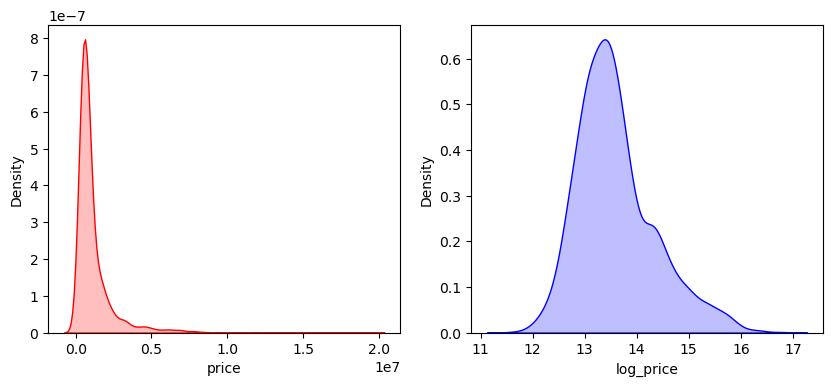

In [44]:
plt.figure(figsize = (10,4))

plt.subplot(1,2,1)
sns.kdeplot( data = df['price'], color = 'red', fill = True)

plt.subplot(1,2,2)
sns.kdeplot( data = df['log_price'], color = 'blue', fill = True)

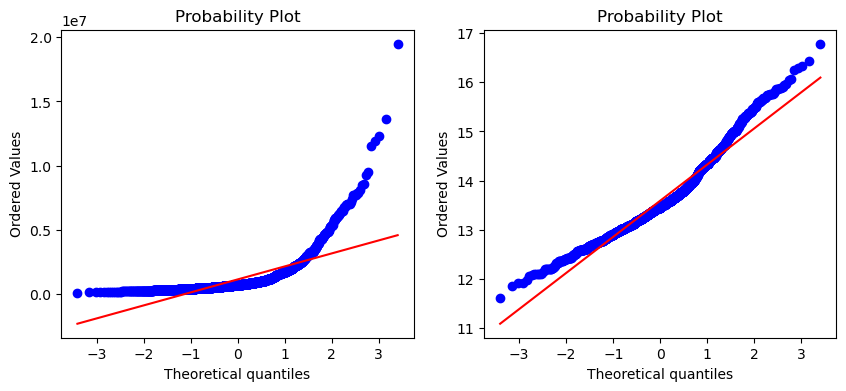

In [45]:
plt.figure(figsize = (10,4))

plt.subplot(1,2,1)
st.probplot( x = df['price'], dist = 'norm', plot = plt)

plt.subplot(1,2,2)
st.probplot( x = df['log_price'], dist = 'norm', plot = plt)

plt.show()

<!-- corr/ -->

# Corr

In [46]:
df[['price', 'Age', 'kms_per_year','is_luxury']].corr()

,price,Age,kms_per_year,is_luxury
price,1.000000,-0.265147,0.034258,0.636139
Age,-0.265147,1.000000,0.009642,0.082001
kms_per_year,0.034258,0.009642,1.000000,0.062489
is_luxury,0.636139,0.082001,0.062489,1.000000


# Model Training

In [47]:
features = ['Age','kms_per_year','is_luxury']
X = df[features]
y = df['log_price']

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [49]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size =0.2, random_state = 42)

In [50]:
model = LinearRegression()
model

LinearRegression()

In [51]:
model.fit(X_train, y_train)

LinearRegression()

In [52]:
y_pred = model.predict(X_test)

In [53]:
mae= mean_absolute_error(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print('mae: ',mae)

print('rmse: ',rmse)

print('r2: ',r2)

mae:  0.3576580845486616
rmse:  0.22401044803732104
r2:  0.6026754577417208


# multiple Models

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [55]:
models = {
    "Linear Regression" : LinearRegression(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest" : RandomForestRegressor(n_estimators = 100),
    "Gradient Boosting" : GradientBoostingRegressor() 
}

In [56]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)

    results.append([name, r2, mae, rmse])

In [57]:
results

[['Linear Regression',
  0.6026754577417208,
  0.3576580845486616,
  0.22401044803732104],
 ['Decision Tree', 0.2873684614365709, 0.4656535757920815, 0.4017796366964613],
 ['Random Forest', 0.5084063999812563, 0.3919761851064356, 0.2771590749631921],
 ['Gradient Boosting',
  0.5814124435686,
  0.35831865351970094,
  0.23599847501514726]]

In [58]:
results_df = pd.DataFrame(results, columns = ['Model','R2','MSE','RMSE'])
results_df.sort_values(by = "R2",ascending = False)

,Model,R2,MSE,RMSE
0,Linear Regression,0.602675,0.357658,0.224010
3,Gradient Boosting,0.581412,0.358319,0.235998
2,Random Forest,0.508406,0.391976,0.277159
1,Decision Tree,0.287368,0.465654,0.401780


# Linear Regression Fine Tuning

In [59]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

In [60]:
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.01,0.1,1,10,100]}

ridge = Ridge()
grid = GridSearchCV(ridge, params, cv = 5, scoring = "r2")
grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 10}
0.481630405409759


In [61]:
params = {'alpha': [0.01,0.1,1,10,100]}

lasso = Lasso()
grid = GridSearchCV(lasso , params, cv = 5, scoring = 'r2')
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 0.01}
0.48266434712930895


In [62]:
params = {'alpha': [0.01,0.1,1,10,100]}

elasticnet = ElasticNet()
grid = GridSearchCV(elasticnet , params, cv = 5, scoring = 'r2')
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'alpha': 0.01}
0.48187022971559534


In [63]:
model = Ridge(alpha = 10)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print('mae: ',mae)

print('rmse: ',rmse)

print('r2: ',r2)

mae:  0.3585532880070154
rmse:  0.22466088242342497
r2:  0.601521790370435


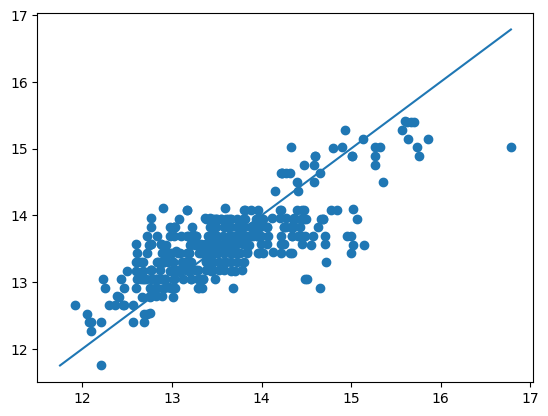

In [69]:
plt.scatter(y_test, y_pred)

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val])

In [64]:
import joblib

joblib.dump(model, "ridge_model.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']